In [3]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:13pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:5xpt;} 
</style>
"""))

In [4]:
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# 1. 기존의 프로그램 방식

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [5]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

섭씨온도는?0
화씨온도는  32.0


# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)

## 2.1 노이즈가 없는 데이터로 실습

In [6]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [7]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [8]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [9]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
               input_shape=(1,) # 입력(독립)변수의 shape
               ))
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


-  회귀분석 오차함수 : 
    MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [10]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
               # 손실함수          옵티마저이저      평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [11]:
# 학습 전 예측
model.predict(np.array([[0],
                        [0.01]]))

1/1 [==============================] - 4s 4s/step


array([[ 0.        ],
       [-0.00816427]], dtype=float32)

In [12]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b이 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [13]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                #  독립변수        타겟변수(종속)   학습횟수    학습시출력여부

Epoch 1/1000
4/4 - 1s - loss: 3.1631 - mae: 1.6107 - 1s/epoch - 252ms/step
Epoch 2/1000
4/4 - 0s - loss: 3.1230 - mae: 1.5993 - 36ms/epoch - 9ms/step
Epoch 3/1000
4/4 - 0s - loss: 3.0945 - mae: 1.5910 - 38ms/epoch - 10ms/step
Epoch 4/1000
4/4 - 0s - loss: 3.0690 - mae: 1.5835 - 34ms/epoch - 8ms/step
Epoch 5/1000
4/4 - 0s - loss: 3.0477 - mae: 1.5773 - 31ms/epoch - 8ms/step
Epoch 6/1000
4/4 - 0s - loss: 3.0258 - mae: 1.5711 - 31ms/epoch - 8ms/step
Epoch 7/1000
4/4 - 0s - loss: 3.0051 - mae: 1.5650 - 53ms/epoch - 13ms/step
Epoch 8/1000
4/4 - 0s - loss: 2.9849 - mae: 1.5590 - 28ms/epoch - 7ms/step
Epoch 9/1000
4/4 - 0s - loss: 2.9650 - mae: 1.5532 - 28ms/epoch - 7ms/step
Epoch 10/1000
4/4 - 0s - loss: 2.9453 - mae: 1.5473 - 30ms/epoch - 7ms/step
Epoch 11/1000
4/4 - 0s - loss: 2.9258 - mae: 1.5416 - 27ms/epoch - 7ms/step
Epoch 12/1000
4/4 - 0s - loss: 2.9042 - mae: 1.5352 - 25ms/epoch - 6ms/step
Epoch 13/1000
4/4 - 0s - loss: 2.8837 - mae: 1.5290 - 28ms/epoch - 7ms/step
Epoch 14/1000
4/4 -

Epoch 109/1000
4/4 - 0s - loss: 1.3423 - mae: 0.9780 - 27ms/epoch - 7ms/step
Epoch 110/1000
4/4 - 0s - loss: 1.3309 - mae: 0.9732 - 30ms/epoch - 7ms/step
Epoch 111/1000
4/4 - 0s - loss: 1.3171 - mae: 0.9674 - 28ms/epoch - 7ms/step
Epoch 112/1000
4/4 - 0s - loss: 1.3054 - mae: 0.9623 - 28ms/epoch - 7ms/step
Epoch 113/1000
4/4 - 0s - loss: 1.2933 - mae: 0.9571 - 32ms/epoch - 8ms/step
Epoch 114/1000
4/4 - 0s - loss: 1.2806 - mae: 0.9517 - 28ms/epoch - 7ms/step
Epoch 115/1000
4/4 - 0s - loss: 1.2688 - mae: 0.9468 - 26ms/epoch - 6ms/step
Epoch 116/1000
4/4 - 0s - loss: 1.2567 - mae: 0.9415 - 29ms/epoch - 7ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.2433 - mae: 0.9357 - 30ms/epoch - 8ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.2314 - mae: 0.9305 - 28ms/epoch - 7ms/step
Epoch 119/1000
4/4 - 0s - loss: 1.2186 - mae: 0.9251 - 28ms/epoch - 7ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.2065 - mae: 0.9198 - 26ms/epoch - 6ms/step
Epoch 121/1000
4/4 - 0s - loss: 1.1944 - mae: 0.9145 - 28ms/epoch - 7ms/step

Epoch 216/1000
4/4 - 0s - loss: 0.3955 - mae: 0.5189 - 32ms/epoch - 8ms/step
Epoch 217/1000
4/4 - 0s - loss: 0.3914 - mae: 0.5167 - 27ms/epoch - 7ms/step
Epoch 218/1000
4/4 - 0s - loss: 0.3870 - mae: 0.5138 - 30ms/epoch - 7ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.3819 - mae: 0.5108 - 33ms/epoch - 8ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.3759 - mae: 0.5072 - 30ms/epoch - 7ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.3709 - mae: 0.5042 - 37ms/epoch - 9ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.3659 - mae: 0.5013 - 33ms/epoch - 8ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.3614 - mae: 0.4985 - 30ms/epoch - 7ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.3577 - mae: 0.4963 - 30ms/epoch - 7ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.3530 - mae: 0.4934 - 32ms/epoch - 8ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.3495 - mae: 0.4912 - 31ms/epoch - 8ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.3448 - mae: 0.4883 - 34ms/epoch - 8ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.3408 - mae: 0.4859 - 35ms/epoch - 9ms/step

Epoch 323/1000
4/4 - 0s - loss: 0.1641 - mae: 0.3506 - 31ms/epoch - 8ms/step
Epoch 324/1000
4/4 - 0s - loss: 0.1632 - mae: 0.3496 - 27ms/epoch - 7ms/step
Epoch 325/1000
4/4 - 0s - loss: 0.1625 - mae: 0.3488 - 27ms/epoch - 7ms/step
Epoch 326/1000
4/4 - 0s - loss: 0.1618 - mae: 0.3481 - 29ms/epoch - 7ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.1613 - mae: 0.3475 - 30ms/epoch - 8ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.1606 - mae: 0.3468 - 29ms/epoch - 7ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.1598 - mae: 0.3458 - 30ms/epoch - 7ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.1590 - mae: 0.3449 - 28ms/epoch - 7ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.1584 - mae: 0.3443 - 31ms/epoch - 8ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.1577 - mae: 0.3436 - 31ms/epoch - 8ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.1571 - mae: 0.3429 - 29ms/epoch - 7ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.1565 - mae: 0.3423 - 29ms/epoch - 7ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.1556 - mae: 0.3412 - 27ms/epoch - 7ms/step

Epoch 430/1000
4/4 - 0s - loss: 0.0934 - mae: 0.2640 - 31ms/epoch - 8ms/step
Epoch 431/1000
4/4 - 0s - loss: 0.0928 - mae: 0.2631 - 27ms/epoch - 7ms/step
Epoch 432/1000
4/4 - 0s - loss: 0.0922 - mae: 0.2622 - 38ms/epoch - 9ms/step
Epoch 433/1000
4/4 - 0s - loss: 0.0917 - mae: 0.2614 - 30ms/epoch - 8ms/step
Epoch 434/1000
4/4 - 0s - loss: 0.0911 - mae: 0.2606 - 27ms/epoch - 7ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.0906 - mae: 0.2599 - 27ms/epoch - 7ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.0900 - mae: 0.2590 - 33ms/epoch - 8ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.0894 - mae: 0.2581 - 33ms/epoch - 8ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.0888 - mae: 0.2572 - 34ms/epoch - 9ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.0883 - mae: 0.2564 - 35ms/epoch - 9ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.0877 - mae: 0.2556 - 36ms/epoch - 9ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.0871 - mae: 0.2547 - 28ms/epoch - 7ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.0865 - mae: 0.2540 - 30ms/epoch - 7ms/step

Epoch 537/1000
4/4 - 0s - loss: 0.0408 - mae: 0.1746 - 29ms/epoch - 7ms/step
Epoch 538/1000
4/4 - 0s - loss: 0.0404 - mae: 0.1737 - 32ms/epoch - 8ms/step
Epoch 539/1000
4/4 - 0s - loss: 0.0399 - mae: 0.1727 - 36ms/epoch - 9ms/step
Epoch 540/1000
4/4 - 0s - loss: 0.0396 - mae: 0.1719 - 32ms/epoch - 8ms/step
Epoch 541/1000
4/4 - 0s - loss: 0.0392 - mae: 0.1711 - 31ms/epoch - 8ms/step
Epoch 542/1000
4/4 - 0s - loss: 0.0388 - mae: 0.1702 - 28ms/epoch - 7ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.0384 - mae: 0.1694 - 28ms/epoch - 7ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.0381 - mae: 0.1685 - 33ms/epoch - 8ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.0377 - mae: 0.1678 - 36ms/epoch - 9ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.0372 - mae: 0.1667 - 30ms/epoch - 7ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.0368 - mae: 0.1657 - 31ms/epoch - 8ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.0364 - mae: 0.1649 - 30ms/epoch - 7ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.0361 - mae: 0.1640 - 27ms/epoch - 7ms/step

Epoch 644/1000
4/4 - 0s - loss: 0.0103 - mae: 0.0877 - 28ms/epoch - 7ms/step
Epoch 645/1000
4/4 - 0s - loss: 0.0101 - mae: 0.0868 - 34ms/epoch - 9ms/step
Epoch 646/1000
4/4 - 0s - loss: 0.0099 - mae: 0.0859 - 31ms/epoch - 8ms/step
Epoch 647/1000
4/4 - 0s - loss: 0.0097 - mae: 0.0850 - 28ms/epoch - 7ms/step
Epoch 648/1000
4/4 - 0s - loss: 0.0095 - mae: 0.0841 - 33ms/epoch - 8ms/step
Epoch 649/1000
4/4 - 0s - loss: 0.0094 - mae: 0.0834 - 28ms/epoch - 7ms/step
Epoch 650/1000
4/4 - 0s - loss: 0.0092 - mae: 0.0828 - 32ms/epoch - 8ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0090 - mae: 0.0819 - 30ms/epoch - 7ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0088 - mae: 0.0811 - 27ms/epoch - 7ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0087 - mae: 0.0803 - 27ms/epoch - 7ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0085 - mae: 0.0795 - 28ms/epoch - 7ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0083 - mae: 0.0787 - 29ms/epoch - 7ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0081 - mae: 0.0779 - 29ms/epoch - 7ms/step

Epoch 749/1000
4/4 - 0s - loss: 4.7419e-05 - mae: 0.0060 - 27ms/epoch - 7ms/step
Epoch 750/1000
4/4 - 0s - loss: 3.8128e-05 - mae: 0.0053 - 28ms/epoch - 7ms/step
Epoch 751/1000
4/4 - 0s - loss: 3.0289e-05 - mae: 0.0047 - 29ms/epoch - 7ms/step
Epoch 752/1000
4/4 - 0s - loss: 2.3209e-05 - mae: 0.0041 - 33ms/epoch - 8ms/step
Epoch 753/1000
4/4 - 0s - loss: 1.5777e-05 - mae: 0.0034 - 31ms/epoch - 8ms/step
Epoch 754/1000
4/4 - 0s - loss: 1.0967e-05 - mae: 0.0028 - 34ms/epoch - 9ms/step
Epoch 755/1000
4/4 - 0s - loss: 7.8028e-06 - mae: 0.0024 - 30ms/epoch - 7ms/step
Epoch 756/1000
4/4 - 0s - loss: 6.5498e-06 - mae: 0.0022 - 32ms/epoch - 8ms/step
Epoch 757/1000
4/4 - 0s - loss: 3.0656e-06 - mae: 0.0015 - 30ms/epoch - 8ms/step
Epoch 758/1000
4/4 - 0s - loss: 1.6728e-06 - mae: 0.0011 - 27ms/epoch - 7ms/step
Epoch 759/1000
4/4 - 0s - loss: 1.0482e-06 - mae: 8.2957e-04 - 28ms/epoch - 7ms/step
Epoch 760/1000
4/4 - 0s - loss: 4.5073e-07 - mae: 5.6713e-04 - 27ms/epoch - 7ms/step
Epoch 761/1000
4/4 -

Epoch 847/1000
4/4 - 0s - loss: 3.5526e-07 - mae: 5.4728e-04 - 38ms/epoch - 10ms/step
Epoch 848/1000
4/4 - 0s - loss: 2.1433e-07 - mae: 4.4946e-04 - 30ms/epoch - 8ms/step
Epoch 849/1000
4/4 - 0s - loss: 5.8121e-07 - mae: 7.3195e-04 - 31ms/epoch - 8ms/step
Epoch 850/1000
4/4 - 0s - loss: 7.3341e-07 - mae: 8.3823e-04 - 30ms/epoch - 8ms/step
Epoch 851/1000
4/4 - 0s - loss: 8.6428e-07 - mae: 9.0051e-04 - 32ms/epoch - 8ms/step
Epoch 852/1000
4/4 - 0s - loss: 1.9738e-07 - mae: 4.3443e-04 - 31ms/epoch - 8ms/step
Epoch 853/1000
4/4 - 0s - loss: 5.0166e-07 - mae: 6.8449e-04 - 25ms/epoch - 6ms/step
Epoch 854/1000
4/4 - 0s - loss: 6.6974e-07 - mae: 8.0265e-04 - 33ms/epoch - 8ms/step
Epoch 855/1000
4/4 - 0s - loss: 8.3119e-07 - mae: 8.8669e-04 - 31ms/epoch - 8ms/step
Epoch 856/1000
4/4 - 0s - loss: 4.6982e-07 - mae: 6.7076e-04 - 27ms/epoch - 7ms/step
Epoch 857/1000
4/4 - 0s - loss: 4.1890e-07 - mae: 6.2913e-04 - 39ms/epoch - 10ms/step
Epoch 858/1000
4/4 - 0s - loss: 7.7323e-07 - mae: 8.5890e-04 - 

Epoch 944/1000
4/4 - 0s - loss: 7.1583e-07 - mae: 8.2350e-04 - 31ms/epoch - 8ms/step
Epoch 945/1000
4/4 - 0s - loss: 4.4201e-07 - mae: 6.4708e-04 - 30ms/epoch - 8ms/step
Epoch 946/1000
4/4 - 0s - loss: 5.7106e-07 - mae: 7.3979e-04 - 31ms/epoch - 8ms/step
Epoch 947/1000
4/4 - 0s - loss: 8.2851e-07 - mae: 8.8607e-04 - 25ms/epoch - 6ms/step
Epoch 948/1000
4/4 - 0s - loss: 3.6374e-07 - mae: 5.8721e-04 - 31ms/epoch - 8ms/step
Epoch 949/1000
4/4 - 0s - loss: 6.2953e-07 - mae: 7.7561e-04 - 32ms/epoch - 8ms/step
Epoch 950/1000
4/4 - 0s - loss: 4.0476e-07 - mae: 6.2248e-04 - 33ms/epoch - 8ms/step
Epoch 951/1000
4/4 - 0s - loss: 7.6706e-07 - mae: 8.5784e-04 - 28ms/epoch - 7ms/step
Epoch 952/1000
4/4 - 0s - loss: 8.2492e-07 - mae: 8.6639e-04 - 33ms/epoch - 8ms/step
Epoch 953/1000
4/4 - 0s - loss: 2.9183e-07 - mae: 5.2550e-04 - 36ms/epoch - 9ms/step
Epoch 954/1000
4/4 - 0s - loss: 7.4543e-07 - mae: 8.4681e-04 - 30ms/epoch - 8ms/step
Epoch 955/1000
4/4 - 0s - loss: 2.7423e-07 - mae: 5.1423e-04 - 33

In [14]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

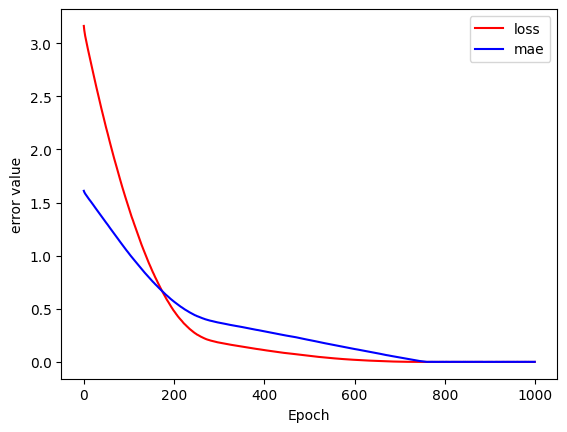

In [15]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [16]:
# 모델 사용
model.predict(np.array([[0],
                        [0.01],
                        [0.02]]))

1/1 [==============================] - 0s 51ms/step


array([[0.32051706],
       [0.3385265 ],
       [0.3565359 ]], dtype=float32)

In [17]:
model.save('model/after_learning.h5')

In [17]:
# 모델 load
from tensorflow.keras.models import load_model
model = load_model('model/after_learning.h5')

In [18]:
model.predict(np.array([[0],
                        [0.01],
                        [0.02]]))

1/1 [==============================] - 0s 99ms/step


array([[0.32051706],
       [0.3385265 ],
       [0.3565359 ]], dtype=float32)

In [20]:
y_hat = model.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 #mean square error(mse)

4/4 [==============================] - 0s 4ms/step


1.0421932128504565e-06

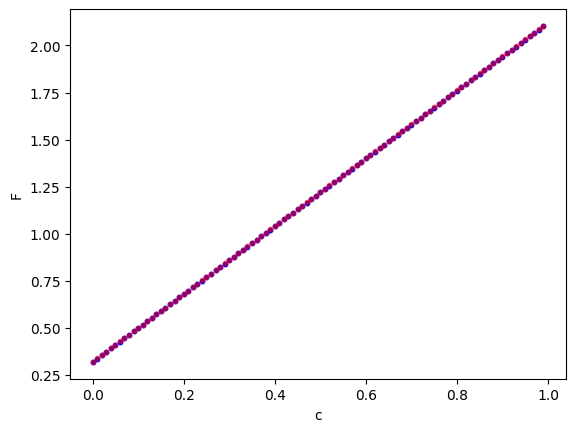

In [22]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', s=10)
plt.scatter(x=scaled_data_C, y=y_hat, c='r', s=10, alpha=0.5)
plt.xlabel('c')
plt.ylabel('F')
plt.show()

## 2.2 노이즈가 있는 데이터로 실습

In [30]:
# 평균이 0이고 표준편차가 0.1인 넘파이 배열을 생성(size만큼)
np.random.seed(707)
nois = np.random.normal(0, scale=0.1, size=100)
noised_scaled_data_F = nois + scaled_data_F
noised_scaled_data_F

array([0.27500034, 0.20410134, 0.39498826, 0.27117424, 0.26897164,
       0.35314388, 0.4496784 , 0.42612159, 0.49409646, 0.45740286,
       0.31574183, 0.67996337, 0.46117139, 0.66152189, 0.45319086,
       0.4519712 , 0.73018132, 0.54170904, 0.68386841, 0.75022628,
       0.65735179, 0.76512782, 0.57019861, 0.79130977, 0.62965251,
       0.60058611, 0.81087191, 0.79345666, 0.90825121, 0.80020546,
       0.8489619 , 0.72808603, 0.98336163, 0.78173322, 0.8212351 ,
       1.05542797, 0.86566002, 0.99728791, 1.14628604, 0.93021808,
       0.91091956, 1.20887357, 0.89807223, 1.08124513, 0.95949964,
       1.24417872, 1.47029141, 0.89345844, 1.24009232, 1.26965718,
       1.39203371, 1.20086793, 1.17335862, 1.18484202, 1.26527807,
       1.25914114, 1.25582658, 1.46684352, 1.42267387, 1.38347091,
       1.34554506, 1.45325705, 1.58244673, 1.31622328, 1.38397926,
       1.53624202, 1.36919068, 1.51482044, 1.6480895 , 1.69886349,
       1.60323679, 1.68203012, 1.53758531, 1.57779451, 1.73967

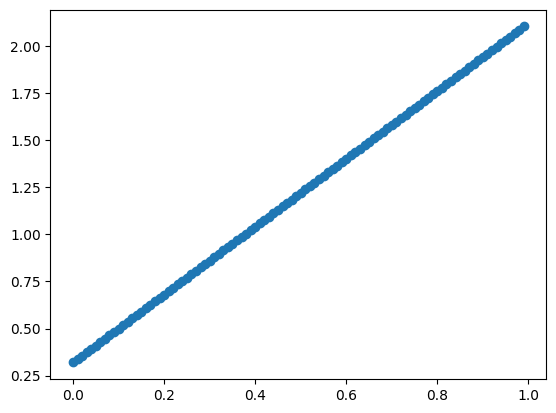

In [31]:
plt.scatter(x=scaled_data_C, y=scaled_data_F)

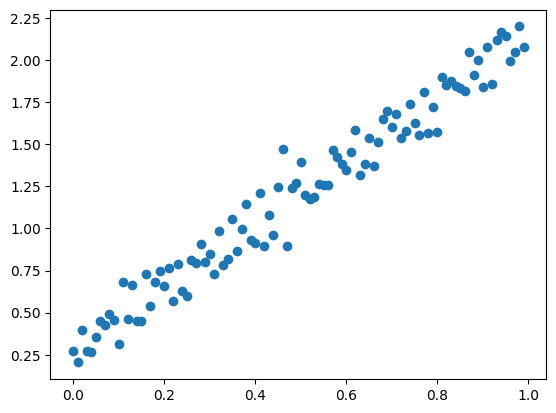

In [32]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [34]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model2 = Sequential()
model2.add(Dense(units=1, input_shape=(1, ))) # units출력갯수, input_shape입력shape
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
               # 손실함수           # 옵티마이저         # 평가지표
print(model2.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


In [35]:
# 5. 학습시키기
hist2 = model2.fit(scaled_data_C,
                  noised_scaled_data_F,
                  epochs=1000,
                  verbose=1)

Epoch 1/1000
4/4 [==============================] - 1s 11ms/step - loss: 1.6587 - mae: 1.1727
Epoch 2/1000
4/4 [==============================] - 0s 8ms/step - loss: 1.6292 - mae: 1.1611
Epoch 3/1000
4/4 [==============================] - 0s 9ms/step - loss: 1.6086 - mae: 1.1528
Epoch 4/1000
4/4 [==============================] - 0s 10ms/step - loss: 1.5912 - mae: 1.1459
Epoch 5/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.5751 - mae: 1.1394
Epoch 6/1000
4/4 [==============================] - 0s 8ms/step - loss: 1.5595 - mae: 1.1330
Epoch 7/1000
4/4 [==============================] - 0s 9ms/step - loss: 1.5456 - mae: 1.1274
Epoch 8/1000
4/4 [==============================] - 0s 9ms/step - loss: 1.5304 - mae: 1.1212
Epoch 9/1000
4/4 [==============================] - 0s 10ms/step - loss: 1.5155 - mae: 1.1151
Epoch 10/1000
4/4 [==============================] - 0s 8ms/step - loss: 1.5019 - mae: 1.1095
Epoch 11/1000
4/4 [==============================] - 0s 9ms/step 

4/4 [==============================] - 0s 11ms/step - loss: 0.1542 - mae: 0.3271
Epoch 174/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.1513 - mae: 0.3249
Epoch 175/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.1494 - mae: 0.3233
Epoch 176/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1466 - mae: 0.3211
Epoch 177/1000
4/4 [==============================] - 0s 15ms/step - loss: 0.1436 - mae: 0.3186
Epoch 178/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1421 - mae: 0.3172
Epoch 179/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.1400 - mae: 0.3155
Epoch 180/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1378 - mae: 0.3136
Epoch 181/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.1360 - mae: 0.3119
Epoch 182/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.1343 - mae: 0.3103
Epoch 183/1000
4/4 [==============================] - 0s 

4/4 [==============================] - 0s 9ms/step - loss: 0.0726 - mae: 0.2290
Epoch 260/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0722 - mae: 0.2283
Epoch 261/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0716 - mae: 0.2275
Epoch 262/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0713 - mae: 0.2269
Epoch 263/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0706 - mae: 0.2259
Epoch 264/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0701 - mae: 0.2249
Epoch 265/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0696 - mae: 0.2240
Epoch 266/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0691 - mae: 0.2231
Epoch 267/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0687 - mae: 0.2225
Epoch 268/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0682 - mae: 0.2216
Epoch 269/1000
4/4 [==============================] - 0s 10ms

4/4 [==============================] - 0s 9ms/step - loss: 0.0399 - mae: 0.1686
Epoch 346/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0396 - mae: 0.1679
Epoch 347/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0393 - mae: 0.1671
Epoch 348/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0390 - mae: 0.1666
Epoch 349/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0386 - mae: 0.1658
Epoch 350/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0384 - mae: 0.1652
Epoch 351/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0381 - mae: 0.1647
Epoch 352/1000
4/4 [==============================] - 0s 21ms/step - loss: 0.0379 - mae: 0.1643
Epoch 353/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0377 - mae: 0.1637
Epoch 354/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0374 - mae: 0.1632
Epoch 355/1000
4/4 [==============================] - 0s 9ms/s

4/4 [==============================] - 0s 9ms/step - loss: 0.0127 - mae: 0.0938
Epoch 518/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0127 - mae: 0.0937
Epoch 519/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0127 - mae: 0.0937
Epoch 520/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0126 - mae: 0.0936
Epoch 521/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0126 - mae: 0.0933
Epoch 522/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0126 - mae: 0.0932
Epoch 523/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0125 - mae: 0.0931
Epoch 524/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0125 - mae: 0.0928
Epoch 525/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.0124 - mae: 0.0928
Epoch 526/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0124 - mae: 0.0926
Epoch 527/1000
4/4 [==============================] - 0s 10

4/4 [==============================] - 0s 7ms/step - loss: 0.0111 - mae: 0.0888
Epoch 604/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0111 - mae: 0.0886
Epoch 605/1000
4/4 [==============================] - 0s 7ms/step - loss: 0.0111 - mae: 0.0884
Epoch 606/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0111 - mae: 0.0883
Epoch 607/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0111 - mae: 0.0882
Epoch 608/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0111 - mae: 0.0883
Epoch 609/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0111 - mae: 0.0883
Epoch 610/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0111 - mae: 0.0883
Epoch 611/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0111 - mae: 0.0881
Epoch 612/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0111 - mae: 0.0880
Epoch 613/1000
4/4 [==============================] - 0s 10ms

4/4 [==============================] - 0s 8ms/step - loss: 0.0110 - mae: 0.0877
Epoch 776/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0110 - mae: 0.0877
Epoch 777/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0877
Epoch 778/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0877
Epoch 779/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0109 - mae: 0.0877
Epoch 780/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0110 - mae: 0.0878
Epoch 781/1000
4/4 [==============================] - 0s 8ms/step - loss: 0.0110 - mae: 0.0881
Epoch 782/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0879
Epoch 783/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0110 - mae: 0.0880
Epoch 784/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0878
Epoch 785/1000
4/4 [==============================] - 0s 10ms/st

4/4 [==============================] - 0s 8ms/step - loss: 0.0110 - mae: 0.0878
Epoch 862/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0878
Epoch 863/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0110 - mae: 0.0878
Epoch 864/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0110 - mae: 0.0878
Epoch 865/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0109 - mae: 0.0877
Epoch 866/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0109 - mae: 0.0876
Epoch 867/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0877
Epoch 868/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0879
Epoch 869/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0877
Epoch 870/1000
4/4 [==============================] - 0s 10ms/step - loss: 0.0110 - mae: 0.0877
Epoch 871/1000
4/4 [==============================] - 0s 10ms

In [37]:
hist2.history.keys()

dict_keys(['loss', 'mae'])

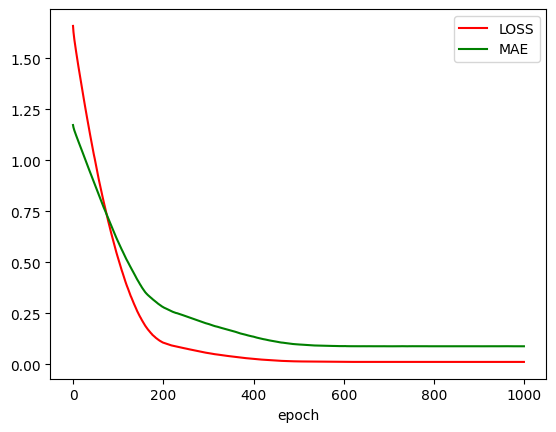

In [47]:
plt.plot(hist2.history['loss'], 'r', label='LOSS')
plt.plot(hist2.history['mae'], 'g', label='MAE')
plt.legend()
plt.xlabel('epoch')
plt.show()

In [50]:
y_hat = model2.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, noised_scaled_data_F):
    square_error += (h[0]-y)**2
square_error/100

4/4 [==============================] - 0s 5ms/step


0.010945954722394052

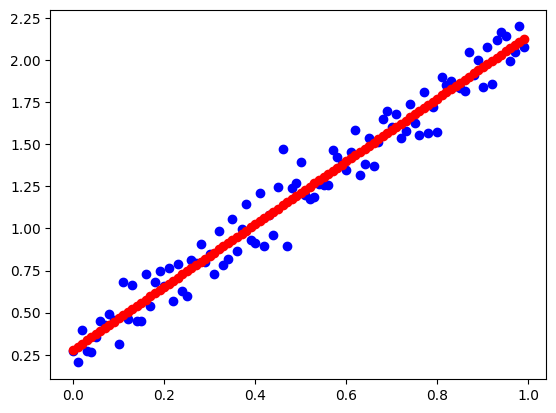

In [51]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F, c='b')
plt.scatter(x=scaled_data_C, y=y_hat, c='r')